In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from constants import RESULTS_DIR, BEST_OF_BEST_DIR

In [2]:
# -------------------------
# Read from best_orthogonal.csv
# -------------------------
fname = f'{BEST_OF_BEST_DIR}/best_orthogonal.csv'
df = pd.read_csv(fname, skipinitialspace=True)

In [3]:
print(f"Total rows: {len(df)}")
print(f"Total unique arbors: {df['arbor name'].nunique()}")

Total rows: 147801
Total unique arbors: 2423


In [4]:
# -------------------------
# For each arbor, count how many rows it has
# (multiple rows = tied best G/alpha combinations)
# -------------------------
tie_counts = df.groupby('arbor name').agg(
    n_tied_total  = ('arbor name', 'count'),
    n_tied_G      = ('best G', 'nunique'),
    n_tied_alpha  = ('best alpha', 'nunique'),
    best_orth     = ('best orthogonal distance', 'first'),
).reset_index()
tie_counts

,arbor name,n_tied_total,n_tied_G,n_tied_alpha,best_orth
0,pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...,1,1,1,20.091197
1,pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...,1,1,1,364.677005
2,pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...,1,1,1,126.900648
3,pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...,1,1,1,241.132021
4,pimpi_ABA_D9_set1_day9_20220610_RSA_M248M058LA...,1,1,1,151.209828
...,...,...,...,...,...
2418,pimpi_IAA1_D9_set1_day9_20211213_RSA_M248M058L...,1,1,1,167.996328
2419,pimpi_IAA1_D9_set1_day9_20211213_RSA_M248M058L...,1,1,1,129.968468
2420,pimpi_IAA1_D9_set1_day9_20211213_RSA_M248M058L...,1,1,1,137.189080
2421,pimpi_IAA1_D9_set1_day9_20211213_RSA_M248M058L...,1,1,1,134.304226


In [7]:
# -------------------------
# Summary
# -------------------------
print(f"\nArbors with single unique optimum: {(tie_counts['n_tied_total'] == 1).sum()}")
print(f"Arbors with multiple tied G values: {(tie_counts['n_tied_G'] > 1).sum()}")
print(f"Arbors with multiple tied alpha values: {(tie_counts['n_tied_alpha'] > 1).sum()}")

print(f"\nDistribution of number of tied G values:")
print(tie_counts['n_tied_G'].value_counts().sort_index())

print(f"\nDistribution of number of tied alpha values:")
print(tie_counts['n_tied_alpha'].value_counts().sort_index())



Arbors with single unique optimum: 1780
Arbors with multiple tied G values: 4
Arbors with multiple tied alpha values: 641

Distribution of number of tied G values:
n_tied_G
1    2419
2       1
3       1
5       1
7       1
Name: count, dtype: int64

Distribution of number of tied alpha values:
n_tied_alpha
1       1782
2          7
3          4
4          6
5          5
        ... 
1440       1
1586       1
1710       1
1851       1
1967       1
Name: count, Length: 215, dtype: int64


In [8]:
# -------------------------
# Arbors with multiple tied G values
# -------------------------
multi_G = tie_counts[tie_counts['n_tied_G'] > 1].sort_values('n_tied_G', ascending=False)
if len(multi_G) > 0:
    print(f"\nArbors with multiple tied G values:")
    print(multi_G.to_string())
else:
    print(f"\nNo arbors with multiple tied G values — G is uniquely identified for all arbors.")


Arbors with multiple tied G values:
                                                                              arbor name  n_tied_total  n_tied_G  n_tied_alpha  best_orth
1727                                   pimpi_Big5_all_day_set1_day4_20191023_306_135_1_S           878         7           303   1.102430
2124  pimpi_GA_D5_set1_day5_20220316_RSA_M248M058LA1511_GA_100mM_Salt123_la1511_3_S_higa           611         5           162   0.047815
557                                       pimpi_Big2_D4D5_set1_day5_20190927_026_251_1_S             3         3             1   1.516573
185         pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA1511_ACC_Salt021_m058_4_S_5acc             2         2             1  77.148026


In [9]:
# -------------------------
# For multi-G arbors, show what G values are tied
# -------------------------
if len(multi_G) > 0:
    print(f"\nTied G values for multi-G arbors:")
    for arbor_name in multi_G['arbor name']:
        G_vals = sorted(df[df['arbor name'] == arbor_name]['best G'].unique())
        print(f"  {arbor_name}: {G_vals}")


Tied G values for multi-G arbors:
  pimpi_Big5_all_day_set1_day4_20191023_306_135_1_S: [2.01214, 2.012199, 2.012755, 2.013311, 2.01337, 2.014422, 2.0146]
  pimpi_GA_D5_set1_day5_20220316_RSA_M248M058LA1511_GA_100mM_Salt123_la1511_3_S_higa: [-3.502506, -3.502494, -3.5, -3.497506, -3.497494]
  pimpi_Big2_D4D5_set1_day5_20190927_026_251_1_S: [1.486689, 1.487245, 1.487801]
  pimpi_ACC_D9_set1_day9_20220624_RSA-M248M058LA1511_ACC_Salt021_m058_4_S_5acc: [-0.012755, -0.012199]


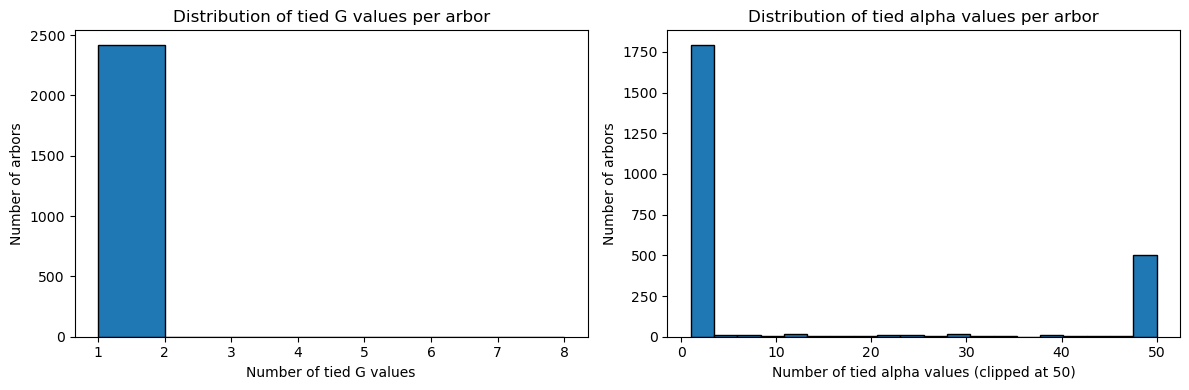

In [10]:
# -------------------------
# Visualize
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tie_counts['n_tied_G'], 
             bins=range(1, tie_counts['n_tied_G'].max() + 2),
             edgecolor='black')
axes[0].set_xlabel('Number of tied G values')
axes[0].set_ylabel('Number of arbors')
axes[0].set_title('Distribution of tied G values per arbor')

axes[1].hist(tie_counts['n_tied_alpha'].clip(upper=50), 
             bins=20, edgecolor='black')
axes[1].set_xlabel('Number of tied alpha values (clipped at 50)')
axes[1].set_ylabel('Number of arbors')
axes[1].set_title('Distribution of tied alpha values per arbor')

plt.tight_layout()
plt.show()